In [1]:
import decoupler as dc
import numpy as np
import pandas as pd
import pertpy as pt
import scanpy as sc
import anndata as  ad

adata = ad.read_h5ad("../data_processed/final_data.h5ad")

c:\Users\asd123cheese\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata.obs["sample"] = pd.Categorical([
    f"{mouse}_{tissue}"
    for mouse, tissue in zip(
        adata.obs["mouse.id"],
        adata.obs["tissue"],
        strict=False
    )
])

In [3]:
adata_pb = dc.pp.pseudobulk(
    adata,
    sample_col="sample",       
    groups_col="major_cell_type",    
    layer="counts",            
    mode="sum"
)

In [4]:
print(f"Pseudobulk shape: {adata_pb.shape}")
# rows = 独立样本×cell_type 组合数, cols = 基因数
n_samples = adata_pb.n_obs   # 这才是"独立样本数"（sample×cell_type）
print(f"独立样本组合数: {n_samples}")

Pseudobulk shape: (250, 20138)
独立样本组合数: 250


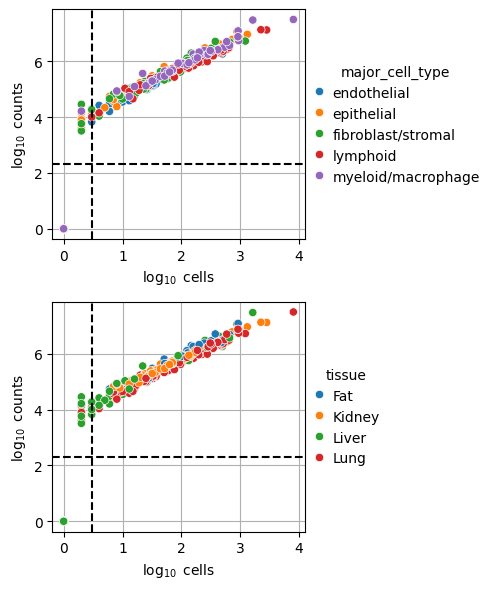

In [11]:
dc.pl.filter_samples(
    adata=adata_pb,
    groupby=[ "major_cell_type", "tissue"],
    min_cells=3,
    min_counts=200,
    figsize=(5,6)
)

In [12]:
dc.pp.filter_samples(adata_pb, min_cells=3,min_counts=200)

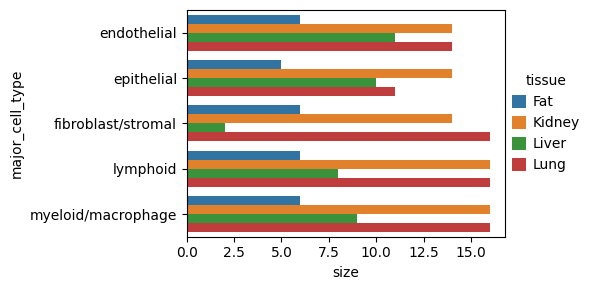

In [14]:
dc.pl.obsbar(adata=adata_pb, y="major_cell_type", hue="tissue", figsize=(6, 3))

In [15]:
adata_pb.write_h5ad("../data_processed/pseudobulk.h5ad")